# Anna Karenina test: does idiosyncratic cognitive abnormality track symptoms?

The CCA ladder found only a small, essentially linear *shared* cognition↔symptom axis. The **Anna Karenina hypothesis** is that symptomatic individuals are each abnormal *in their own way*, so the *magnitude/extremeness* of a person's deviation from healthy cognitive norms should track symptoms even when no shared axis exists.

We build normative models on training-half healthy volunteers (`cogmood_analysis.normative`), score every training subject's deviation (`|z|`) per cognitive parameter, and test three ways (all on **extremeness**, since signed deviations carry a random sign under AK):
- **max|z| / top-k mean** — unsupervised, robust to sparsity (primary AK statistic)
- **elastic-net on |z|** — supervised, learns the relevant subset (out-of-fold r²)
- **distance / count-burden** — dilution-prone baselines

Targets: symptom summary totals + subscales + a general PC1 factor, raw and age/sex-residualized. **PC1 (residualized) is the pre-specified primary**; the rest are FDR-corrected secondary. Significance is by permuting the symptom vector.

**Training half only** — the held-out half is untouched. This notebook loads `data/exploratory/ak_results.parquet` (produced by `cogmood_analysis.anna_karenina.run_ak`).

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
res = pl.read_parquet("../data/exploratory/ak_results.parquet")
print(f"rows: {res.height} | approaches: {res['approach'].unique().to_list()}")
print(f"targets: {res['target'].n_unique()} | variants: {res['variant'].unique().to_list()}")

rows: 252 | approaches: ['top5_mean', 'dist', 'max_abs', 'enet', 'top3_mean', 'count_gt2']
targets: 21 | variants: ['raw', 'resid']


## 1. Primary outcome: PC1 general symptom factor (residualized)

In [2]:
primary = (res.filter((pl.col('target') == 'PC1') & (pl.col('variant') == 'resid'))
             .select(['approach', 'effect', 'effect_kind', 'p', 'n_selected'])
             .with_columns([pl.col('effect').round(3), pl.col('p').round(4)]))
print(primary)
print("\nAll primary p-values > 0.05 -> the pre-specified AK primary is null.")

shape: (6, 5)
┌───────────┬────────┬─────────────┬────────┬────────────┐
│ approach  ┆ effect ┆ effect_kind ┆ p      ┆ n_selected │
│ ---       ┆ ---    ┆ ---         ┆ ---    ┆ ---        │
│ str       ┆ f64    ┆ str         ┆ f64    ┆ i64        │
╞═══════════╪════════╪═════════════╪════════╪════════════╡
│ max_abs   ┆ 0.007  ┆ spearman_r  ┆ 0.3973 ┆ null       │
│ top3_mean ┆ 0.023  ┆ spearman_r  ┆ 0.1939 ┆ null       │
│ top5_mean ┆ 0.029  ┆ spearman_r  ┆ 0.1339 ┆ null       │
│ count_gt2 ┆ 0.041  ┆ spearman_r  ┆ 0.06   ┆ null       │
│ dist      ┆ 0.037  ┆ spearman_r  ┆ 0.0825 ┆ null       │
│ enet      ┆ -0.006 ┆ oof_r2      ┆ 0.1194 ┆ 0          │
└───────────┴────────┴─────────────┴────────┴────────────┘

All primary p-values > 0.05 -> the pre-specified AK primary is null.


## 2. Secondary: effect size by approach across all symptom targets (residualized)

Each point is one symptom target; red = survives BH-FDR (q<0.05) within its approach.

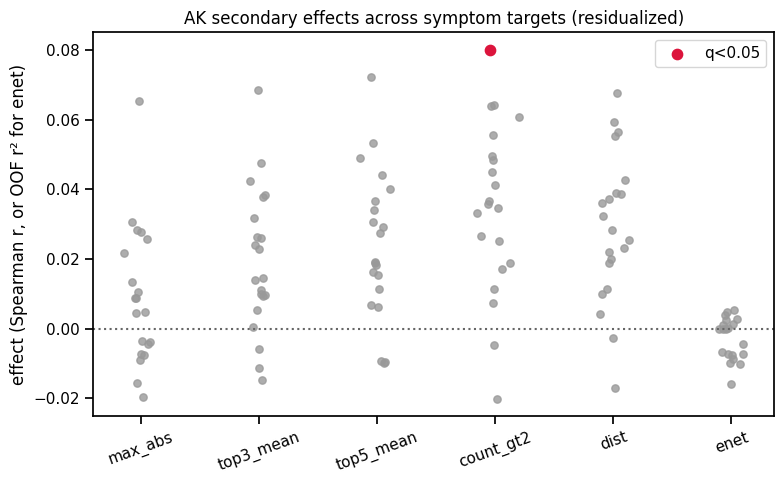

In [3]:
sec = res.filter((pl.col('variant') == 'resid') & (~pl.col('primary')))
approaches = ['max_abs', 'top3_mean', 'top5_mean', 'count_gt2', 'dist', 'enet']
fig, ax = plt.subplots(figsize=(8, 5))
for i, ap in enumerate(approaches):
    d = sec.filter(pl.col('approach') == ap)
    eff = d['effect'].to_numpy(); q = d['fdr_q'].to_numpy()
    x = np.full(len(eff), i) + np.random.default_rng(i).normal(0, 0.06, len(eff))
    ax.scatter(x[q >= 0.05], eff[q >= 0.05], s=28, color='0.6', alpha=0.8)
    ax.scatter(x[q < 0.05], eff[q < 0.05], s=55, color='crimson', zorder=5, label='q<0.05' if i == 0 else None)
ax.axhline(0, ls=':', color='0.4')
ax.set_xticks(range(len(approaches))); ax.set_xticklabels(approaches, rotation=20)
ax.set_ylabel('effect (Spearman r, or OOF r² for enet)')
ax.set_title('AK secondary effects across symptom targets (residualized)')
ax.legend()
plt.tight_layout(); plt.show()

In [4]:
# How many secondary targets survive FDR per approach, and the single hit
summary = (sec.group_by('approach')
              .agg([(pl.col('fdr_q') < 0.05).sum().alias('n_sig'),
                    pl.len().alias('n_tests'),
                    pl.col('effect').abs().max().round(3).alias('max_abs_effect')]))
print(summary.sort('approach'))
print("\nThe only FDR-significant secondary result:")
print(sec.filter(pl.col('fdr_q') < 0.05).select(['approach', 'target', 'effect', 'p', 'fdr_q']))

shape: (6, 4)
┌───────────┬───────┬─────────┬────────────────┐
│ approach  ┆ n_sig ┆ n_tests ┆ max_abs_effect │
│ ---       ┆ ---   ┆ ---     ┆ ---            │
│ str       ┆ u32   ┆ u32     ┆ f64            │
╞═══════════╪═══════╪═════════╪════════════════╡
│ count_gt2 ┆ 1     ┆ 21      ┆ 0.08           │
│ dist      ┆ 0     ┆ 21      ┆ 0.068          │
│ enet      ┆ 0     ┆ 20      ┆ 0.016          │
│ max_abs   ┆ 0     ┆ 20      ┆ 0.065          │
│ top3_mean ┆ 0     ┆ 21      ┆ 0.068          │
│ top5_mean ┆ 0     ┆ 21      ┆ 0.072          │
└───────────┴───────┴─────────┴────────────────┘

The only FDR-significant secondary result:
shape: (1, 5)
┌───────────┬──────────────┬──────────┬──────────┬──────────┐
│ approach  ┆ target       ┆ effect   ┆ p        ┆ fdr_q    │
│ ---       ┆ ---          ┆ ---      ┆ ---      ┆ ---      │
│ str       ┆ str          ┆ f64      ┆ f64      ┆ f64      │
╞═══════════╪══════════════╪══════════╪══════════╪══════════╡
│ count_gt2 ┆ hitop_hypsom ┆ 0

## 3. Permutation p-value distribution (secondary tests)

Under a true null with valid permutation tests, p-values are ~uniform. A spike near 0 would indicate real signal; here they are close to uniform.

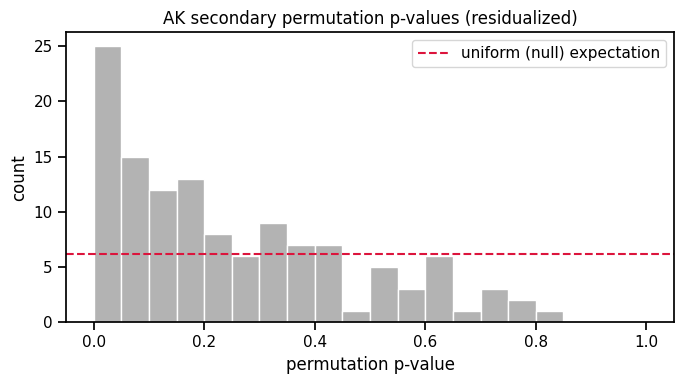

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sec['p'].to_numpy(), bins=20, range=(0, 1), color='0.7', edgecolor='white')
ax.axhline(sec.height / 20, ls='--', color='crimson', label='uniform (null) expectation')
ax.set_xlabel('permutation p-value'); ax.set_ylabel('count')
ax.set_title('AK secondary permutation p-values (residualized)')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Conclusion

**The Anna Karenina hypothesis is not supported in the training half.**

- **Primary** (PC1 general factor, residualized): every approach is null — max|z| r≈0.01 (p≈0.40), supervised elastic-net OOF r²<0 with 0 features selected.
- **Secondary**: of ~120 FDR-corrected tests, exactly one survives (`count_gt2 → HiTOP hypersomnia`, r=0.08, q=0.03) — a single hit at that scale is most consistent with chance, and effect sizes everywhere are tiny (|r| ≤ 0.08; best OOF r² ≈ 0.5%).
- Permutation p-values are ~uniform, consistent with no genuine deviation→symptom relationship.

This matches the CCA-ladder null: the fitted cognitive-model parameters carry very little information about symptoms in this sample — whether the relationship is modeled as *shared* (CCA) or *idiosyncratic* (AK).

**Recommendation:** do not spend the reserved held-out half confirming this — the training-half exploratory result is null, so a confirmatory test is not warranted. Everything here used the training half only.